In [1]:
import pandas as pd

pd.read_csv('/Facebook_Marketplace_data.csv')

,status_id,status_type,status_published,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,Column1,Column2,Column3,Column4
0,1,video,4/22/2018 6:00,529,512,262,432,92,3,1,1,0,NaN,NaN,NaN,NaN
1,2,photo,4/21/2018 22:45,150,0,0,150,0,0,0,0,0,NaN,NaN,NaN,NaN
2,3,video,4/21/2018 6:17,227,236,57,204,21,1,1,0,0,NaN,NaN,NaN,NaN
3,4,photo,4/21/2018 2:29,111,0,0,111,0,0,0,0,0,NaN,NaN,NaN,NaN
4,5,photo,4/18/2018 3:22,213,0,0,204,9,0,0,0,0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7045,7046,photo,9/24/2016 2:58,89,0,0,89,0,0,0,0,0,NaN,NaN,NaN,NaN
7046,7047,photo,9/23/2016 11:19,16,0,0,14,1,0,1,0,0,NaN,NaN,NaN,NaN
7047,7048,photo,9/21/2016 23:03,2,0,0,1,1,0,0,0,0,NaN,NaN,NaN,NaN
7048,7049,photo,9/20/2016 0:43,351,12,22,349,2,0,0,0,0,NaN,NaN,NaN,NaN


In [ ]:
Project-1
Using the facebook market place dataset

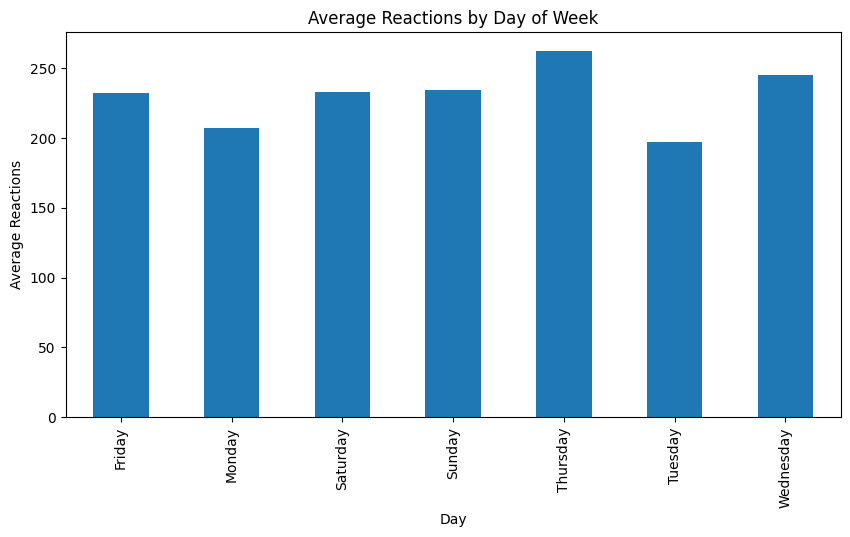

NameError: name 'y' is not defined

In [2]:
from sklearn.cluster import KMeans
import pandas as pd
import matplotlib.pyplot as plt

data=pd.read_csv('/Facebook_Marketplace_data.csv')
X=data['status_published']=pd.to_datetime(data['status_published'])
data['hour'] = data['status_published'].dt.hour
data['day'] = data['status_published'].dt.day_name()
data['month'] = data['status_published'].dt.month
avg_by_day = data.groupby('day')['num_reactions'].mean()


avg_by_day.plot(kind='bar', figsize=(10,5))
plt.title("Average Reactions by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Reactions")
plt.show()




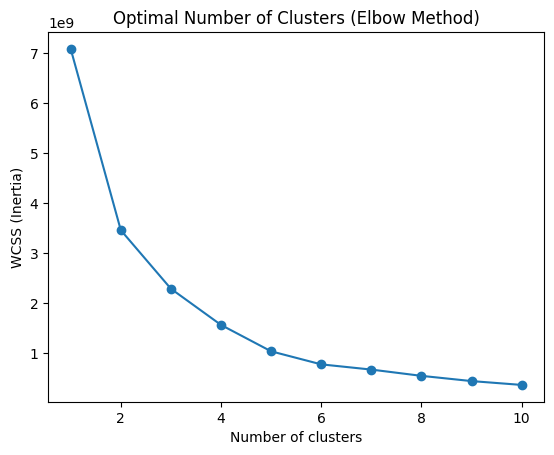

In [5]:
from sklearn.cluster import KMeans
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
data = pd.read_csv('/Facebook_Marketplace_data.csv')

# Select features for clustering (2D array)
X = data[['num_reactions', 'num_comments']].values

# Calculate WCSS for different cluster counts
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=80)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)   # inertia_ gives WCSS

# Plot elbow curve
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS (Inertia)')
plt.title('Optimal Number of Clusters (Elbow Method)')
plt.show()

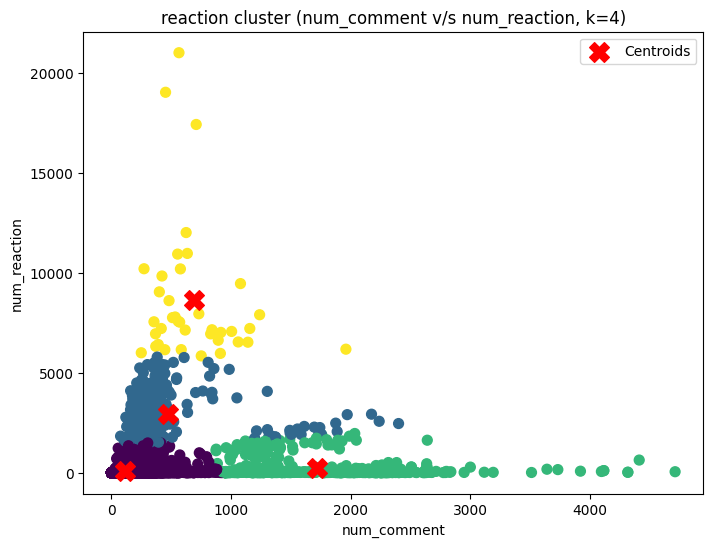

In [16]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import pandas as pd

data=pd.read_csv('/Facebook_Marketplace_data.csv')

X = data[['num_reactions', 'num_comments']].values

kmeans = KMeans(n_clusters=4, random_state=80)
y_kmeans = kmeans.fit_predict(X)

plt.figure(figsize=(8,6))
plt.scatter(X[:,0], X[:,1], c=y_kmeans, cmap='viridis', s=50)

plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1],
            c='red', marker='X', s=200, label='Centroids')
plt.xlabel('num_comment')
plt.ylabel('num_reaction')
plt.title('reaction cluster (num_comment v/s num_reaction, k=4)')
plt.legend()
plt.show()



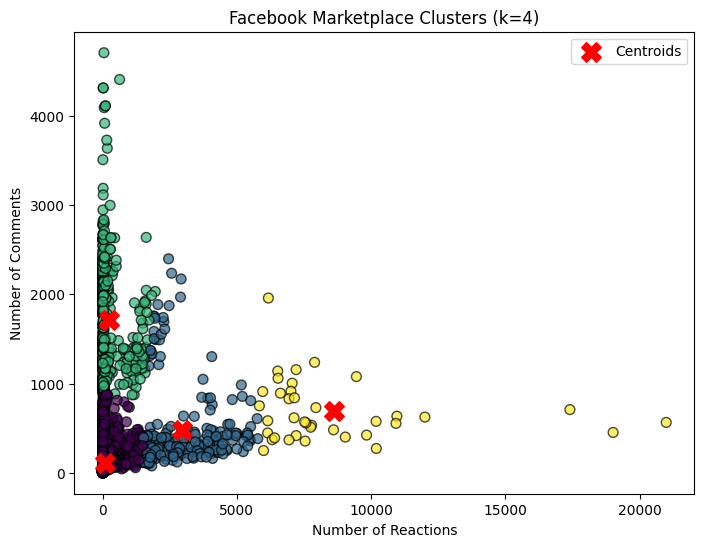

In [11]:
from sklearn.cluster import KMeans
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv('/Facebook_Marketplace_data.csv')

X=data[['num_comments','num_reactions']].values

kmeans=KMeans(n_clusters=4,random_state=80, n_init='auto')
y_kmeans = kmeans.fit_predict(X) # Fit the model to get cluster assignments and populate cluster_centers_


plt.figure(figsize=(8,6))
plt.scatter(X[:,0], X[:,1], c=y_kmeans, cmap='viridis', s=50, edgecolors='k', alpha=0.7)



plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1],
            c='red', marker='X', s=200, label='Centroids')

plt.xlabel('Number of Reactions')
plt.ylabel('Number of Comments')
plt.title('Facebook Marketplace Clusters (k=4)')
plt.legend()
plt.show()

In [12]:
import pandas as pd

pd.read_csv('/Facebook_Marketplace_data.csv')

averages=data.groupby('status_type')[['num_reactions','num_comments','num_shares']].mean()

print(averages)

             num_reactions  num_comments  num_shares
status_type                                         
link            370.142857      5.698413    4.396825
photo           181.290345     15.993470    2.553871
status          438.783562     36.238356    2.558904
video           283.409597    642.478149  115.679949


In [13]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Load dataset
data = pd.read_csv('/Facebook_Marketplace_data.csv')

# Select relevant columns
features = ['status_type','num_reactions','num_comments','num_shares',
            'num_likes','num_loves','num_wows','num_hahas','num_sads','num_angrys']

X = data[features]

# Encode categorical column (status_type)
X = pd.get_dummies(X, columns=['status_type'], drop_first=True)

# Scale numeric features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

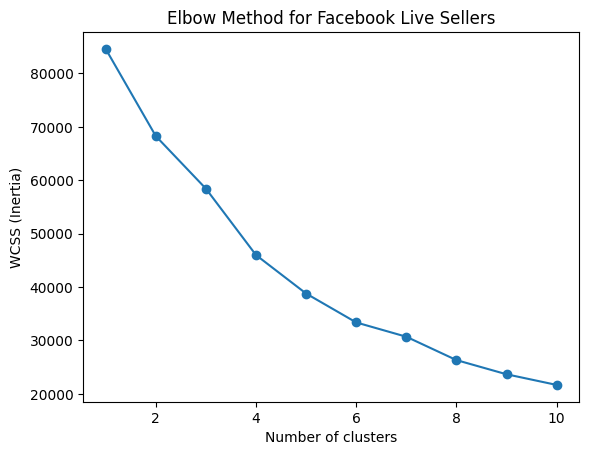

In [14]:
import matplotlib.pyplot as plt

# Elbow method
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=80)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS (Inertia)')
plt.title('Elbow Method for Facebook Live Sellers')
plt.show()

# Train final model (example: k=4)
kmeans = KMeans(n_clusters=4, random_state=80)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to dataset
data['Cluster'] = clusters

In [17]:
import pandas as pd

# Load dataset
data = pd.read_csv('/Facebook_Marketplace_data.csv')

# Count different post types
post_counts = data['status_type'].value_counts()

print(post_counts)

status_type
photo     4288
video     2334
status     365
link        63
Name: count, dtype: int64


In [15]:
cluster_summary = data.groupby('Cluster')[['num_reactions','num_comments','num_shares',
                                           'num_likes','num_loves','num_wows',
                                           'num_hahas','num_sads','num_angrys']].mean()

print(cluster_summary)

         num_reactions  num_comments  ...  num_sads  num_angrys
Cluster                               ...                      
0            93.507503     11.808777  ...  0.125284    0.024102
1           168.477698    387.592326  ...  0.240767    0.143885
2          1821.218329     60.824798  ...  0.032345    0.005391
3           939.448980   3566.729592  ...  3.331633    1.989796

[4 rows x 9 columns]
